In [1]:
import pandas as pd
import seaborn as sns

from scipy.stats import kruskal
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Control

C:\Users\tr432\Downloads\filter_GutLungAxis_Control


In [3]:
## qzv 파일 Qiime2View에 넣고 'Download raw data as TSV' 로 다운받은 후 파일명만 바꿔서 사용
df_week_shannon = pd.read_csv('shannon.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'shannon_entropy'])
df_week_faith = pd.read_csv('faith.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'faith_pd'])
df_week_observed = pd.read_csv('observed.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'observed_features'])
df_week_pielou = pd.read_csv('pielou.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'pielou_evenness'])

print(df_week_shannon.head(3))
print(df_week_faith.head(3))
print(df_week_observed.head(3))
print(df_week_pielou.head(3))

       id SamplingWeek  shannon_entropy
0  C01-1w        Week1         6.685379
1  C01-2w        Week2         6.833082
2  C02-1w        Week1         6.682147
       id SamplingWeek   faith_pd
0  C01-1w        Week1  19.862428
1  C01-2w        Week2  23.923465
2  C02-1w        Week1  20.464353
       id SamplingWeek  observed_features
0  C01-1w        Week1                306
1  C01-2w        Week2                471
2  C02-1w        Week1                346
       id SamplingWeek  pielou_evenness
0  C01-1w        Week1         0.807010
1  C01-2w        Week2         0.763529
2  C02-1w        Week1         0.787836


In [4]:
## Group 종류 확인
print(df_week_shannon.SamplingWeek.unique())
print(df_week_faith.SamplingWeek.unique())
print(df_week_observed.SamplingWeek.unique())
print(df_week_pielou.SamplingWeek.unique())

['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']


Statistic: 8.30
P-value: 1.58e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.385e-01 Stat=2.195e+00
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.442e-02 Stat=4.040e+00
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:9.522e-03 Stat=6.722e+00


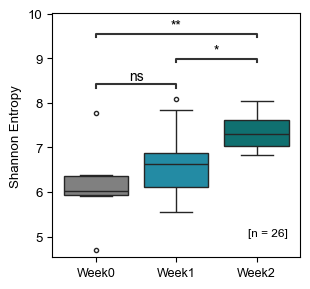

In [5]:
## shannon


data = df_week_shannon
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['shannon_entropy']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['shannon_entropy']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['shannon_entropy']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Shannon Entropy', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower right',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('weeks_shannon.tiff', dpi=300, bbox_inches='tight')

Statistic: 2.96
P-value: 2.27e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:2.706e-01 Stat=1.214e+00
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.078e-01 Stat=2.586e+00
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.795e-01 Stat=5.000e-01


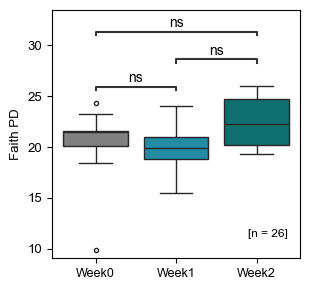

In [6]:
## faith_pd


data = df_week_faith
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['faith_pd']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['faith_pd']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['faith_pd']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Faith PD', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower right',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('weeks_faith.tiff', dpi=300, bbox_inches='tight')

Statistic: 4.96
P-value: 8.40e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:6.214e-01 Stat=2.439e-01
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.442e-02 Stat=4.040e+00
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:5.935e-02 Stat=3.556e+00


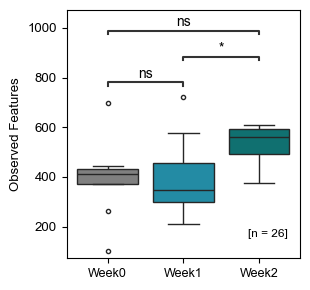

In [7]:
## observed_features


data = df_week_observed
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['observed_features']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['observed_features']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['observed_features']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Observed Features', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower right',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('weeks_observed.tiff', dpi=300, bbox_inches='tight')

Statistic: 9.03
P-value: 1.10e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:3.668e-02 Stat=4.365e+00
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.594e-01 Stat=1.980e+00
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:6.717e-03 Stat=7.347e+00


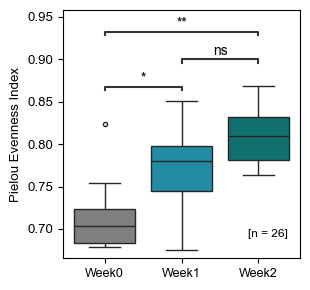

In [8]:
## pielou_evenness


data = df_week_pielou
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['pielou_evenness']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['pielou_evenness']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['pielou_evenness']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Pielou Evenness Index', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower right',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('weeks_pielou.tiff', dpi=300, bbox_inches='tight')

In [15]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_VNAM

C:\Users\tr432\Downloads\filter_GutLungAxis_VNAM


In [16]:
## qzv 파일 Qiime2View에 넣고 'Download raw data as TSV' 로 다운받은 후 파일명만 바꿔서 사용
df_week_shannon = pd.read_csv('shannon.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'shannon_entropy'])
df_week_faith = pd.read_csv('faith.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'faith_pd'])
df_week_observed = pd.read_csv('observed.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'observed_features'])
df_week_pielou = pd.read_csv('pielou.tsv', sep='\t', skiprows=[1],
                        usecols=['id', 'SamplingWeek', 'pielou_evenness'])

print(df_week_shannon.head(3))
print(df_week_faith.head(3))
print(df_week_observed.head(3))
print(df_week_pielou.head(3))

       id SamplingWeek  shannon_entropy
0  V01-1w        Week1         3.609338
1  V01-2w        Week2         2.509272
2  V02-1w        Week1         2.340640
       id SamplingWeek  faith_pd
0  V01-1w        Week1  7.056026
1  V01-2w        Week2  4.016756
2  V02-1w        Week1  5.522684
       id SamplingWeek  observed_features
0  V01-1w        Week1                 69
1  V01-2w        Week2                 29
2  V02-1w        Week1                 34
       id SamplingWeek  pielou_evenness
0  V01-1w        Week1         0.582894
1  V01-2w        Week2         0.512220
2  V02-1w        Week1         0.456911


In [17]:
## Group 종류 확인
print(df_week_shannon.SamplingWeek.unique())
print(df_week_faith.SamplingWeek.unique())
print(df_week_observed.SamplingWeek.unique())
print(df_week_pielou.SamplingWeek.unique())

['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']
['Week1' 'Week2' 'Week0']


Statistic: 13.33
P-value: 1.27e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.000e+00 Stat=0.000e+00
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


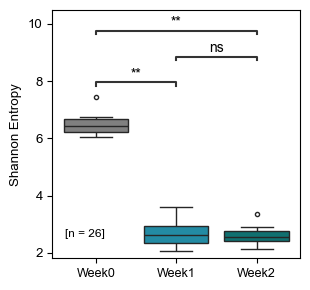

In [19]:
## shannon


data = df_week_shannon
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['shannon_entropy']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['shannon_entropy']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['shannon_entropy']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Shannon Entropy', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
plt.savefig('weeks_shannon.tiff', dpi=800, bbox_inches='tight')

Statistic: 13.39
P-value: 1.24e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:7.624e-01 Stat=9.143e-02
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


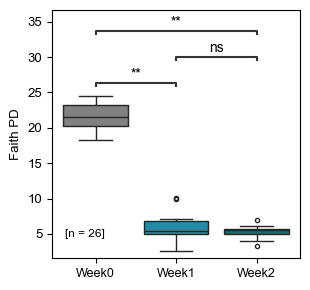

In [20]:
## faith_pd


data = df_week_faith
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['faith_pd']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['faith_pd']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['faith_pd']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Faith PD', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
plt.savefig('weeks_faith.tiff', dpi=800, bbox_inches='tight')

Statistic: 13.37
P-value: 1.25e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.119e-03 Stat=1.062e+01
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:9.095e-01 Stat=1.292e-02
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.119e-03 Stat=1.062e+01


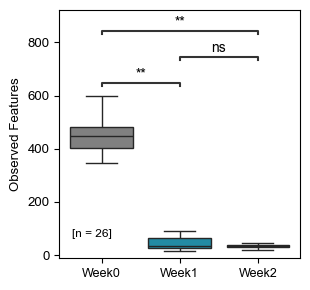

In [21]:
## observed_features


data = df_week_observed
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['observed_features']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['observed_features']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['observed_features']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Observed Features', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
plt.savefig('weeks_observed.tiff', dpi=800, bbox_inches='tight')

Statistic: 13.35
P-value: 1.26e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0 vs. Week1: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01
Week1 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:8.798e-01 Stat=2.286e-02
Week0 vs. Week2: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


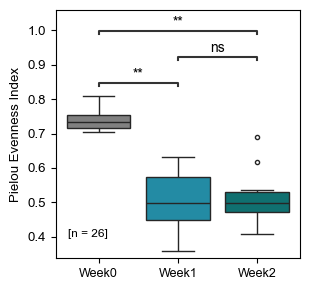

In [22]:
## pielou_evenness


data = df_week_pielou
feat = data.columns[2]  ## AlphaDiv 지표 열 의미함
#orders = data.SamplingWeek.unique()  ## SamplingWeek 종류 의미함
orders = ["Week0", "Week1", "Week2"]

#Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
#VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit
week0 = data[data['SamplingWeek'] == 'Week0']['pielou_evenness']  #Edit
week1 = data[data['SamplingWeek'] == 'Week1']['pielou_evenness']  #Edit
week2 = data[data['SamplingWeek'] == 'Week2']['pielou_evenness']  #Edit


stat, p = kruskal(week0, week1, week2)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['gray', '#0D98BA', 'teal']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='SamplingWeek', y=feat, palette=palette, fliersize=3, order=orders)


pairs = [("Week0", "Week1"), ("Week0", "Week2"), ("Week1", "Week2")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='SamplingWeek', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Pielou Evenness Index', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

#label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
label = f'[n = {data.shape[0]}]'
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
plt.savefig('weeks_pielou.tiff', dpi=800, bbox_inches='tight')